# Setup E - Effective Sample Size for PAT Rig NIR Measurement

Level-controlled vertical PAT rig with a side-window non-contact NIR probe, deterministic first-generation model

## Background

Setup E models a PAT (Process Analytical Technology) rig as a **vertical cylindrical sampling interface** fed continuously from an upstream manufacturing unit. A rotating outlet valve at the bottom controls discharge, while level sensors along the wall maintain the rig at approximately **half full** during operation.

The primary NIR instrument views the powder through a side optical window positioned near the lower part of the rig. In the base case used here, the measurement location is placed **one-quarter of the rig height above the bottom outlet** and the non-contact NIR spot diameter is **25 mm**.

Three distinct mass metrics are relevant:

1. **Instantaneous probed mass** ($m_{inst}$): mass simultaneously illuminated at any single instant.
2. **New mass presented per acquisition** ($m_{new}$): unique material refreshed across the NIR spot during one acquisition time, bounded by the instantaneous mass.
3. **Mass passed probe footprint** ($m_{pass}$): total mass that crosses the probe footprint during acquisition and is not bounded by the instantaneous mass.

This notebook treats the occupied lower section of the PAT rig as a first-order dense moving powder column. It uses the maintained fill level to determine whether the probe is covered by powder and then uses throughput-driven axial motion to estimate renewal at the probe position.

## Objective

Compute instantaneous probed mass, new mass presented per acquisition, and mass passed the NIR spot footprint for a level-controlled PAT rig configuration. Use a half-filled base case with the measurement window located one-quarter of the rig height from the bottom, sweep acquisition time and throughput, and export results using the standard reporting workflow.

## Theory

### Covered-probe PAT rig geometry

The PAT rig is represented as a vertical cylindrical flow region observed through a side optical window. The operating assumption in this notebook is that the process is controlled so the probe window is always buried in powder during normal operation. Probe coverage is therefore treated as guaranteed rather than modeled as a variable.

### Throughput-driven axial velocity

Powder motion near the covered probe is approximated as a first-order dense moving column. The axial velocity is estimated from throughput and the full cylindrical cross-section:

$$v = \frac{\dot{m}}{\rho_{bulk} \cdot A_{pipe}}$$

where

$$A_{pipe} = \pi \left(\frac{D_{pipe}}{2}\right)^2$$

This remains a simplifying assumption: it ignores detailed wall slip, outlet-valve kinematics, and any nonuniform velocity profile near the probe.

### Instantaneous probed mass

The non-contact NIR spot is represented as a circular optical footprint with area:

$$A_{spot} = \pi \left(\frac{D_{spot}}{2}\right)^2$$

The instantaneous probed mass is:

$$m_{inst} = \rho_{bulk} \cdot A_{spot} \cdot d_{pen}$$

### Axial advance and refresh fraction

Axial advance during one acquisition is:

$$\Delta z = v \cdot T_{acq}$$

The axial sampling length is represented by a proxy length $L_{axial}$. In the base case this is taken as the NIR spot diameter. The refresh fraction is then:

$$f_{refresh} = \min\!\left(1,\;\frac{\Delta z}{L_{axial}}\right)$$

### New mass and mass passed

New mass presented per acquisition is:

$$m_{new} = f_{refresh} \cdot m_{inst}$$

Mass passed the probe footprint during acquisition is:

$$m_{pass} = \rho_{bulk} \cdot A_{spot} \cdot v \cdot T_{acq}$$

Symbols and units:

- $\dot{m}$: mass flow rate [g/s]
- $\rho_{bulk}$: bulk density [g/cm$^3$]
- $A_{pipe}$: pipe cross-section area [cm$^2$]
- $A_{spot}$: NIR spot area [cm$^2$]
- $D_{spot}$: NIR spot diameter [cm]
- $d_{pen}$: measurement (penetration) depth [cm]
- $T_{acq}$: spectral acquisition time [s]
- $L_{axial}$: axial sampling length proxy [cm]

## Interpreting Density, Velocity, and Throughput

At fixed mass throughput, the local powder velocity in this model is inversely proportional to bulk density:

$$
v = \frac{\dot{m}}{\rho_{bulk} \cdot A_{pipe}}
$$

This means that, for the same throughput in kg/h and the same PAT rig cross-section, lower bulk-density powder occupies a larger volumetric flow rate and therefore moves faster past the probe, while higher bulk-density powder moves more slowly.

This relationship has two important consequences for the present model:

1. Increasing bulk density increases the instantaneous mass in the optical region because the same illuminated volume contains more mass.
2. Increasing bulk density decreases the local axial velocity, which reduces how quickly new material replaces the powder already in view.

These two effects oppose each other. As a result, some modeled outputs separate strongly across bulk density, while others partially collapse or become less sensitive than a reader might first expect.

The notebook therefore treats bulk density as an important material property not only because it changes the illuminated mass directly, but also because it changes the local transport rate that controls refresh behavior during one spectral acquisition.

## Time- and Space-Weighted Contribution to the Spectrum

The notebook distinguishes between three different ideas:

1. the instantaneous mass in the optical region at any one moment
2. the total unique powder illuminated at least once during an acquisition
3. the effective contribution of that powder to the integrated spectrum

The third quantity is the most analytically relevant, because a measured NIR spectrum is a time-integrated signal. Some powder parcels are present in the probe field for longer than others and therefore contribute more strongly to the final spectrum, even if all parcels are counted equally as unique material.

A fully general model would represent this using a time- and space-dependent weighting field $W(\\mathbf{x}, t)$, so that the contribution of a parcel depends on both where it is within the optical sensitivity field and how long it remains there during acquisition.

This notebook does not unfold the full space-time weighting model. Instead, it introduces a simpler first-generation proxy based only on time integration under a top-hat intensity assumption. That proxy is useful for indicating how integrated spectral exposure grows with acquisition time, but it should not be interpreted as a full optical weighting model.

## Assumptions

- vertical cylindrical PAT rig with top feed and bottom discharge through a rotating outlet valve
- the operating window is controlled so the probe window remains continuously covered during normal operation
- no explicit level-control dynamics are modeled because probe coverage is treated as guaranteed by design
- the powder near the probe is treated as a dense moving column
- powder velocity at the probe is approximated from throughput and full pipe cross-section
- the NIR spot is circular and viewed through a side optical window
- measurement depth is small relative to pipe diameter
- axial sampling length is approximated by the NIR spot diameter unless overridden
- no explicit outlet-valve kinematics, turbulence, segregation, or wall-slip correction
- no detailed radiative transfer model yet

## Input Parameters

Baseline covered-probe PAT rig configuration:

- pipe diameter: 10.0 cm (100 mm)
- NIR spot diameter: 2.5 cm (25 mm)
- base-case measurement depth: 0.1 cm (1.0 mm)
- base-case bulk density: 0.5 g/cm$^3$
- density scenarios: 0.4, 0.5, and 0.6 g/cm$^3$
- base-case throughput: 95 kg/h
- base-case acquisition time: 1.0 s
- axial sampling length model: spot diameter

The probe is assumed to remain covered during normal controlled operation, so fill-level dynamics are outside the scope of this notebook.

Sweeps:

- bulk density scenarios: 0.4, 0.5, and 0.6 g/cm$^3$
- penetration depth: 0.1 mm to 2.0 mm in 0.1 mm steps for each bulk density scenario
- acquisition time: 1.0 s to 5.0 s (20 points) for each bulk density scenario
- 3D sweep: throughput 10-100 kg/h x acquisition time 1.0-5.0 s x bulk density scenarios

Internal calculations use CGS units, so penetration depth is computed in cm even when plotted in mm.

In [89]:
import math
from dataclasses import dataclass
from typing import Iterable, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
@dataclass(frozen=True)
class BaseParams:
    # Geometry
    pipe_diameter_cm: float = 10.0
    nir_spot_diameter_cm: float = 2.5
    measurement_depth_cm: float = 0.1  # base case: 1 mm = 0.1 cm

    # Material
    bulk_density_g_per_cm3: float = 0.5

    # Throughput (mass flow on a 3600 s basis)
    throughput_kg: float = 95.0
    throughput_time_s: float = 60.0 * 60.0  # 60 minutes

    # If set, overrides velocity derived from throughput (units: cm/s)
    velocity_override_cm_s: Optional[float] = None

    # Spectral acquisition time (seconds)
    acquisition_time_s: float = 1.0

    # Refresh model: axial sampling length proxy
    # "spot_diameter" or "custom"
    axial_length_model: str = "spot_diameter"
    axial_length_custom_cm: float = 2.5  # used if axial_length_model == "custom"


# Baseline scenario
density_scenarios = [0.4, 0.5, 0.6]
base = BaseParams()

# Input summary table
input_summary_df = pd.DataFrame(
    {
        "parameter": [
            "pipe_diameter_cm",
            "nir_spot_diameter_cm",
            "measurement_depth_cm",
            "bulk_density_g_per_cm3",
            "density_scenarios_g_per_cm3",
            "throughput_kg",
            "throughput_time_s",
            "acquisition_time_s",
            "axial_length_model",
        ],
        "value": [
            base.pipe_diameter_cm,
            base.nir_spot_diameter_cm,
            base.measurement_depth_cm,
            base.bulk_density_g_per_cm3,
            ", ".join(f"{density:.1f}" for density in density_scenarios),
            base.throughput_kg,
            base.throughput_time_s,
            base.acquisition_time_s,
            base.axial_length_model,
        ],
    }
)

input_summary_df

,parameter,value
0,pipe_diameter_cm,10.0
1,nir_spot_diameter_cm,2.5
2,measurement_depth_cm,0.1
3,bulk_density_g_per_cm3,0.5
4,density_scenarios_g_per_cm3,"0.4, 0.5, 0.6"
5,throughput_kg,95.0
6,throughput_time_s,3600.0
7,acquisition_time_s,1.0
8,axial_length_model,spot_diameter


In [ ]:
def area_circle_cm2(d_cm: float) -> float:
    r = d_cm / 2.0
    return math.pi * r * r


def throughput_to_velocity_cm_s(
    pipe_diameter_cm: float,
    bulk_density_g_per_cm3: float,
    throughput_kg: float,
    throughput_time_s: float,
) -> float:
    if pipe_diameter_cm <= 0:
        raise ValueError("pipe_diameter_cm must be > 0")
    if bulk_density_g_per_cm3 <= 0:
        raise ValueError("bulk_density_g_per_cm3 must be > 0")
    if throughput_kg < 0:
        raise ValueError("throughput_kg must be >= 0")
    if throughput_time_s <= 0:
        raise ValueError("throughput_time_s must be > 0")

    mdot_g_s = (throughput_kg * 1000.0) / throughput_time_s
    vdot_cm3_s = mdot_g_s / bulk_density_g_per_cm3
    A_pipe_cm2 = area_circle_cm2(pipe_diameter_cm)
    return vdot_cm3_s / A_pipe_cm2


def axial_sampling_length_cm(params: BaseParams) -> float:
    if params.axial_length_model == "spot_diameter":
        return params.nir_spot_diameter_cm
    if params.axial_length_model == "custom":
        if params.axial_length_custom_cm <= 0:
            raise ValueError("axial_length_custom_cm must be > 0 when using custom model")
        return params.axial_length_custom_cm
    raise ValueError("axial_length_model must be 'spot_diameter' or 'custom'")


def compute_metrics(params: BaseParams) -> Dict[str, float]:
    A_pipe_cm2 = area_circle_cm2(params.pipe_diameter_cm)
    A_spot_cm2 = area_circle_cm2(params.nir_spot_diameter_cm)

    # velocity (cm/s) at the covered probe location
    if params.velocity_override_cm_s is None:
        v_cm_s = throughput_to_velocity_cm_s(
            pipe_diameter_cm=params.pipe_diameter_cm,
            bulk_density_g_per_cm3=params.bulk_density_g_per_cm3,
            throughput_kg=params.throughput_kg,
            throughput_time_s=params.throughput_time_s,
        )
        velocity_source = "derived_from_throughput"
    else:
        if params.velocity_override_cm_s < 0:
            raise ValueError("velocity_override_cm_s must be >= 0")
        v_cm_s = params.velocity_override_cm_s
        velocity_source = "user_override"

    if params.acquisition_time_s <= 0:
        raise ValueError("acquisition_time_s must be > 0")

    # instantaneous sampled mass (mass in view at the covered probe)
    V_probe_cm3 = A_spot_cm2 * params.measurement_depth_cm
    m_inst_g = V_probe_cm3 * params.bulk_density_g_per_cm3

    # refresh / new mass presented over acquisition time
    L_ax_cm = axial_sampling_length_cm(params)
    dz_cm = v_cm_s * params.acquisition_time_s
    raw_refresh_fraction = 0.0 if L_ax_cm == 0 else min(1.0, dz_cm / L_ax_cm)
    f_refresh = raw_refresh_fraction
    m_new_g_per_acq = f_refresh * m_inst_g

    # mass passed the NIR spot footprint during acquisition time
    m_pass_g_per_acq = params.bulk_density_g_per_cm3 * A_spot_cm2 * v_cm_s * params.acquisition_time_s

    # exposure proxy (mass-time)
    m_time_g_s = m_inst_g * params.acquisition_time_s

    # derived flows for reporting
    mdot_g_s = (params.throughput_kg * 1000.0) / params.throughput_time_s
    vdot_cm3_s = mdot_g_s / params.bulk_density_g_per_cm3

    return {
        "setup": "E",
        "pipe_diameter_cm": params.pipe_diameter_cm,
        "pipe_area_cm2": A_pipe_cm2,
        "nir_spot_diameter_cm": params.nir_spot_diameter_cm,
        "nir_spot_area_cm2": A_spot_cm2,
        "measurement_depth_cm": params.measurement_depth_cm,
        "bulk_density_g_per_cm3": params.bulk_density_g_per_cm3,
        "bulk_density_label": f"{params.bulk_density_g_per_cm3:.1f} g/cm^3",
        "throughput_kg": params.throughput_kg,
        "throughput_time_s": params.throughput_time_s,
        "mass_flow_g_s": mdot_g_s,
        "vol_flow_cm3_s": vdot_cm3_s,
        "velocity_source": velocity_source,
        "velocity_cm_s": v_cm_s,
        "velocity_mm_s": v_cm_s * 10.0,
        "acquisition_time_s": params.acquisition_time_s,
        "axial_length_model": params.axial_length_model,
        "axial_sampling_length_cm": L_ax_cm,
        "advance_dz_cm_per_acq": dz_cm,
        "raw_refresh_fraction_per_acq": raw_refresh_fraction,
        "refresh_fraction_per_acq": f_refresh,
        "probe_volume_cm3": V_probe_cm3,
        "probe_mass_g_instant": m_inst_g,
        "probe_mass_mg_instant": m_inst_g * 1000.0,
        "new_mass_g_per_acq": m_new_g_per_acq,
        "new_mass_mg_per_acq": m_new_g_per_acq * 1000.0,
        "mass_passed_g_per_acq": m_pass_g_per_acq,
        "mass_passed_mg_per_acq": m_pass_g_per_acq * 1000.0,
        "mass_time_exposure_g_s": m_time_g_s,
        "mass_time_exposure_mg_s": m_time_g_s * 1000.0,
        "time_weighted_contribution_proxy_g_s": m_time_g_s,
        "time_weighted_contribution_proxy_mg_s": m_time_g_s * 1000.0,
        "effective_sample_size_mg": m_new_g_per_acq * 1000.0,
    }

In [92]:
def linspace_list(start: float, stop: float, n: int) -> List[float]:
    if n < 2:
        return [float(start)]
    return list(np.linspace(start, stop, n))


def run_sweep(base: BaseParams, sweep: Dict[str, Iterable[float]]) -> pd.DataFrame:
    base_fields = set(base.__dataclass_fields__.keys())
    for k in sweep.keys():
        if k not in base_fields:
            raise KeyError(f"Unknown BaseParams field in sweep: '{k}'")

    keys = list(sweep.keys())
    values = [list(sweep[k]) for k in keys]
    grids = np.meshgrid(*values, indexing="ij")
    combos = np.stack([g.ravel() for g in grids], axis=1)

    rows: List[Dict[str, float]] = []
    for combo in combos:
        kwargs = {k: float(v) for k, v in zip(keys, combo)}
        p = BaseParams(**{**base.__dict__, **kwargs})
        rows.append(compute_metrics(p))

    return pd.DataFrame(rows)

## Compute Effective Sample Size Metrics

Run a discrete bulk-density comparison together with a penetration-depth sweep by density, an acquisition-time sweep by density, and a throughput x acquisition-time sweep by density while keeping the covered-probe geometry and 25 mm NIR spot fixed.

In [93]:
penetration_depths_cm = [i / 100.0 for i in range(1, 21)]  # 0.01 to 0.20 cm = 0.1 to 2.0 mm

# Density-only comparison at the base operating condition
sweep_density = {"bulk_density_g_per_cm3": density_scenarios}
df_density = run_sweep(base, sweep_density)
df_density["sweep_type"] = "density"

# 1D sweep: penetration depth x density
sweep_penetration_density = {
    "bulk_density_g_per_cm3": density_scenarios,
    "measurement_depth_cm": penetration_depths_cm,
}
df_penetration_density = run_sweep(base, sweep_penetration_density)
df_penetration_density["sweep_type"] = "penetration_depth_density"

# 1D sweep: acquisition time x density
sweep_acq_density = {
    "bulk_density_g_per_cm3": density_scenarios,
    "acquisition_time_s": linspace_list(1.0, 5.0, 20),
}
df_acq_density = run_sweep(base, sweep_acq_density)
df_acq_density["sweep_type"] = "acquisition_time_density"

# 3D sweep: throughput x acquisition time x density
sweep_3d = {
    "bulk_density_g_per_cm3": density_scenarios,
    "throughput_kg": linspace_list(10, 100, 20),
    "acquisition_time_s": linspace_list(1.0, 5.0, 20),
}
df_3d = run_sweep(base, sweep_3d)
df_3d["sweep_type"] = "throughput_acquisition_density"

# Full results table
results_df = pd.concat([df_density, df_penetration_density, df_acq_density, df_3d], ignore_index=True)

results_df.head(10)

,setup,pipe_diameter_cm,pipe_area_cm2,nir_spot_diameter_cm,nir_spot_area_cm2,measurement_depth_cm,bulk_density_g_per_cm3,bulk_density_label,throughput_kg,throughput_time_s,...,probe_mass_g_instant,probe_mass_mg_instant,new_mass_g_per_acq,new_mass_mg_per_acq,mass_passed_g_per_acq,mass_passed_mg_per_acq,mass_time_exposure_g_s,mass_time_exposure_mg_s,effective_sample_size_mg,sweep_type
0,E,10.0,78.539816,2.5,4.908739,0.10,0.4,0.4 g/cm^3,95.0,3600.0,...,0.196350,196.349541,0.065972,65.972222,1.649306,1649.305556,0.196350,196.349541,65.972222,density
1,E,10.0,78.539816,2.5,4.908739,0.10,0.5,0.5 g/cm^3,95.0,3600.0,...,0.245437,245.436926,0.065972,65.972222,1.649306,1649.305556,0.245437,245.436926,65.972222,density
2,E,10.0,78.539816,2.5,4.908739,0.10,0.6,0.6 g/cm^3,95.0,3600.0,...,0.294524,294.524311,0.065972,65.972222,1.649306,1649.305556,0.294524,294.524311,65.972222,density
3,E,10.0,78.539816,2.5,4.908739,0.01,0.4,0.4 g/cm^3,95.0,3600.0,...,0.019635,19.634954,0.006597,6.597222,1.649306,1649.305556,0.019635,19.634954,6.597222,penetration_depth_density
4,E,10.0,78.539816,2.5,4.908739,0.02,0.4,0.4 g/cm^3,95.0,3600.0,...,0.039270,39.269908,0.013194,13.194444,1.649306,1649.305556,0.039270,39.269908,13.194444,penetration_depth_density
5,E,10.0,78.539816,2.5,4.908739,0.03,0.4,0.4 g/cm^3,95.0,3600.0,...,0.058905,58.904862,0.019792,19.791667,1.649306,1649.305556,0.058905,58.904862,19.791667,penetration_depth_density
6,E,10.0,78.539816,2.5,4.908739,0.04,0.4,0.4 g/cm^3,95.0,3600.0,...,0.078540,78.539816,0.026389,26.388889,1.649306,1649.305556,0.078540,78.539816,26.388889,penetration_depth_density
7,E,10.0,78.539816,2.5,4.908739,0.05,0.4,0.4 g/cm^3,95.0,3600.0,...,0.098175,98.174770,0.032986,32.986111,1.649306,1649.305556,0.098175,98.174770,32.986111,penetration_depth_density
8,E,10.0,78.539816,2.5,4.908739,0.06,0.4,0.4 g/cm^3,95.0,3600.0,...,0.117810,117.809725,0.039583,39.583333,1.649306,1649.305556,0.117810,117.809725,39.583333,penetration_depth_density
9,E,10.0,78.539816,2.5,4.908739,0.07,0.4,0.4 g/cm^3,95.0,3600.0,...,0.137445,137.444679,0.046181,46.180556,1.649306,1649.305556,0.137445,137.444679,46.180556,penetration_depth_density


## Interpretation of the Simulation Table

Each row corresponds to one combination of operating parameters. Key columns:

- **bulk_density_g_per_cm3**: discrete bulk-density scenario used for the calculation
- **measurement_depth_cm**: effective optical penetration depth used to compute illuminated probe volume
- **probe_mass_mg_instant**: mass simultaneously illuminated at any instant
- **new_mass_mg_per_acq**: unique material refreshed during one acquisition
- **mass_passed_mg_per_acq**: total mass crossing the NIR spot footprint during acquisition
- **time_weighted_contribution_proxy_mg_s**: simple time-integrated exposure proxy for the illuminated mass under a top-hat weighting assumption
- **refresh_fraction_per_acq**: fraction of the optical region replaced during acquisition
- **effective_sample_size_mg**: treated here as the refreshed new mass presented per acquisition

Because bulk density enters both the illuminated-mass term and the throughput-derived velocity term, some outputs separate strongly by density while others may partially collapse across the three scenarios.

The time-weighted contribution proxy should be interpreted more cautiously than the refreshed-mass proxy: it tracks how long illuminated mass remains in view, but it does not yet resolve position-dependent optical weighting within the measurement volume.

In [ ]:
# Baseline scenario metrics
base_metrics = compute_metrics(base)

baseline_display = pd.DataFrame(
    [
        {"metric": k, "value": f"{v:.6g}" if isinstance(v, (int, float, np.floating)) else v}
        for k, v in base_metrics.items()
        if k in [
            "bulk_density_g_per_cm3",
            "measurement_depth_cm",
            "velocity_mm_s",
            "probe_mass_mg_instant",
            "acquisition_time_s",
            "new_mass_mg_per_acq",
            "mass_passed_mg_per_acq",
            "time_weighted_contribution_proxy_mg_s",
            "refresh_fraction_per_acq",
            "effective_sample_size_mg",
        ]
    ]
)

baseline_density_display = df_density[
    [
        "bulk_density_g_per_cm3",
        "velocity_mm_s",
        "probe_mass_mg_instant",
        "new_mass_mg_per_acq",
        "mass_passed_mg_per_acq",
        "time_weighted_contribution_proxy_mg_s",
        "refresh_fraction_per_acq",
        "effective_sample_size_mg",
    ]
].copy()

{
    "base_case": baseline_display,
    "density_comparison": baseline_density_display,
}

{'base_case':                      metric     value
 0      measurement_depth_cm       0.1
 1    bulk_density_g_per_cm3       0.5
 2             velocity_mm_s   6.71988
 3        acquisition_time_s         1
 4  refresh_fraction_per_acq  0.268795
 5     probe_mass_mg_instant   245.437
 6       new_mass_mg_per_acq   65.9722
 7    mass_passed_mg_per_acq   1649.31
 8  effective_sample_size_mg   65.9722,
 'density_comparison':    bulk_density_g_per_cm3  velocity_mm_s  probe_mass_mg_instant  \
 0                     0.4       8.399844             196.349541   
 1                     0.5       6.719875             245.436926   
 2                     0.6       5.599896             294.524311   
 
    new_mass_mg_per_acq  mass_passed_mg_per_acq  refresh_fraction_per_acq  \
 0            65.972222             1649.305556                  0.335994   
 1            65.972222             1649.305556                  0.268795   
 2            65.972222             1649.305556                  0.22

## Plot 1: Effective Sample Size vs Penetration Depth for Three Bulk Densities

Shows how the effective sample size proxy changes as the assumed NIR penetration depth increases from 0.1 mm to 2.0 mm for bulk densities of 0.4, 0.5, and 0.6 g/cm$^3$ while the covered-probe geometry, 25 mm NIR spot, throughput, and acquisition time are held at the base case.

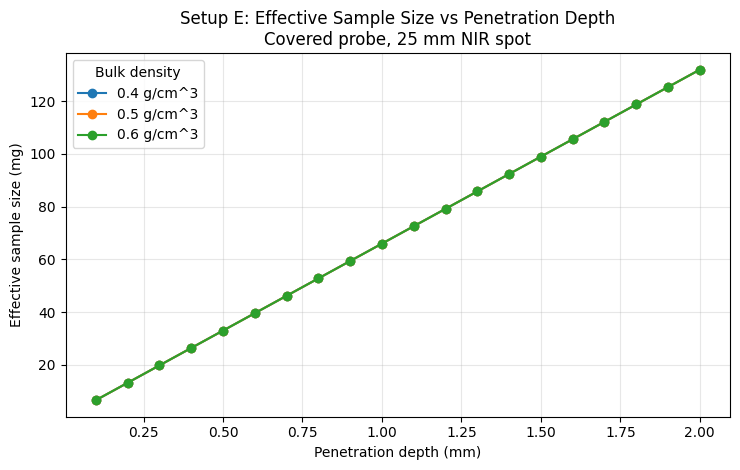

In [95]:
df_pen_sorted = df_penetration_density.sort_values(["bulk_density_g_per_cm3", "measurement_depth_cm"]).copy()
df_pen_sorted["measurement_depth_mm"] = df_pen_sorted["measurement_depth_cm"] * 10.0

fig_eff_sample_vs_depth, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_pen_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(
        group["measurement_depth_mm"],
        group["effective_sample_size_mg"],
        marker="o",
        label=f"{density:.1f} g/cm^3",
    )
ax.set_xlabel("Penetration depth (mm)")
ax.set_ylabel("Effective sample size (mg)")
ax.set_title("Setup E: Effective Sample Size vs Penetration Depth\nCovered probe, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_eff_sample_vs_depth.tight_layout()
plt.show()

## Plot 2: Instantaneous Probed Mass vs Penetration Depth for Three Bulk Densities

This plot isolates the direct mass-scaling effect of density and penetration depth. Unlike refreshed mass, the instantaneous illuminated mass is governed by the local optical volume and the chosen bulk-density scenario.

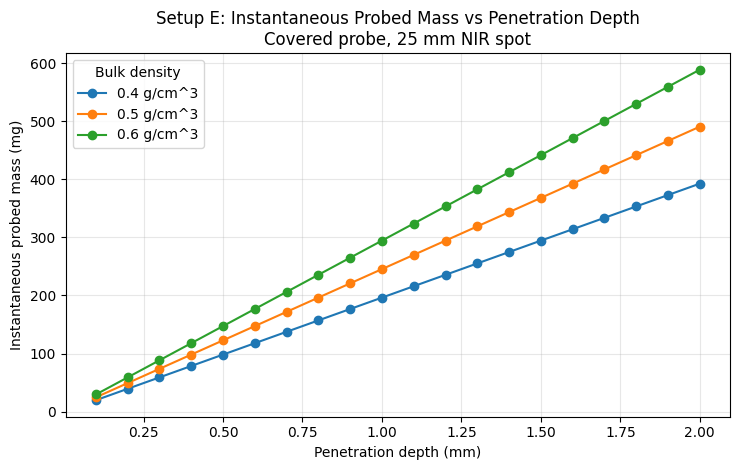

In [96]:
fig_probe_mass_vs_depth, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_pen_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(
        group["measurement_depth_mm"],
        group["probe_mass_mg_instant"],
        marker="o",
        label=f"{density:.1f} g/cm^3",
    )
ax.set_xlabel("Penetration depth (mm)")
ax.set_ylabel("Instantaneous probed mass (mg)")
ax.set_title("Setup E: Instantaneous Probed Mass vs Penetration Depth\nCovered probe, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_probe_mass_vs_depth.tight_layout()
plt.show()

## Plot 3: Effective Sample Size vs Acquisition Time for Three Bulk Densities

Shows how the refreshed new-mass proxy changes as acquisition time increases from 1 s to 5 s for bulk densities of 0.4, 0.5, and 0.6 g/cm$^3$ at fixed penetration depth, throughput, covered-probe geometry, and 25 mm NIR spot.

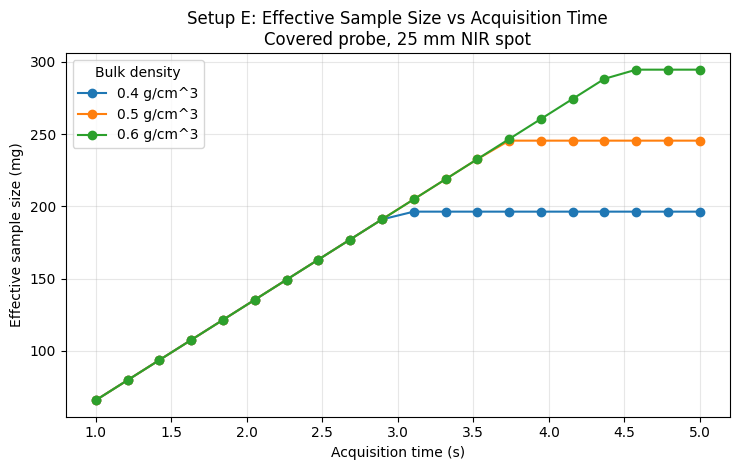

In [97]:
df_acq_sorted = df_acq_density.sort_values(["bulk_density_g_per_cm3", "acquisition_time_s"]).copy()

fig_eff_sample_vs_time, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_acq_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(
        group["acquisition_time_s"],
        group["effective_sample_size_mg"],
        marker="o",
        label=f"{density:.1f} g/cm^3",
    )
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("Effective sample size (mg)")
ax.set_title("Setup E: Effective Sample Size vs Acquisition Time\nCovered probe, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_eff_sample_vs_time.tight_layout()
plt.show()

## Plot 4: Refresh Fraction vs Acquisition Time for Three Bulk Densities

The refresh fraction shows what proportion of the optical region is replaced during one acquisition. In this formulation, density affects the throughput-derived local solids velocity, so the time-to-saturation differs across the three density scenarios.

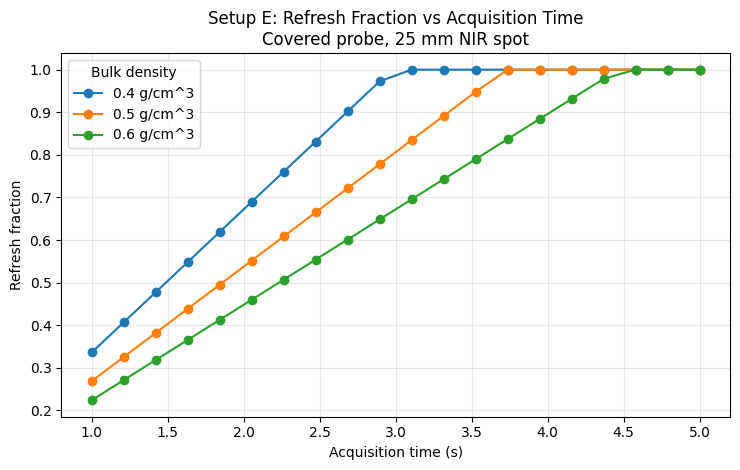

In [98]:
fig_refresh_vs_time, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_acq_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(
        group["acquisition_time_s"],
        group["refresh_fraction_per_acq"],
        marker="o",
        label=f"{density:.1f} g/cm^3",
    )
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("Refresh fraction")
ax.set_title("Setup E: Refresh Fraction vs Acquisition Time\nCovered probe, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_refresh_vs_time.tight_layout()
plt.show()

## Plot 5: Heatmap - Effective Sample Size for 0.4 g/cm$^3$

This operating map shows how the refreshed new-mass proxy depends jointly on throughput and acquisition time for the covered-probe base geometry at a bulk density of 0.4 g/cm$^3$.

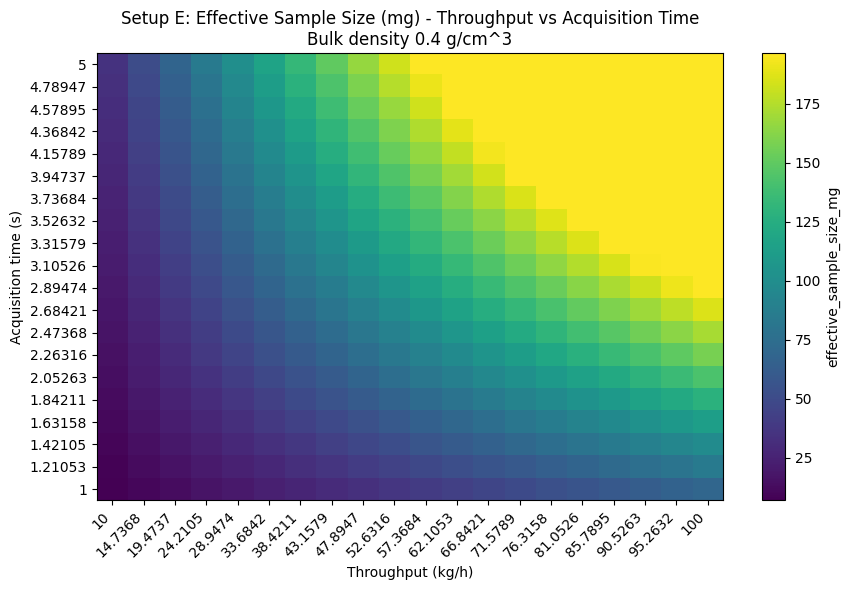

In [99]:
def plot_density_heatmap(dataframe: pd.DataFrame, density: float, figure_title: str):
    filtered = dataframe[dataframe["bulk_density_g_per_cm3"] == density]
    pivot = filtered.pivot_table(
        index="acquisition_time_s", columns="throughput_kg", values="effective_sample_size_mg", aggfunc="mean"
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    image = ax.imshow(pivot.values, aspect="auto", origin="lower")
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels([f"{value:g}" for value in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels([f"{value:g}" for value in pivot.index])
    ax.set_xlabel("Throughput (kg/h)")
    ax.set_ylabel("Acquisition time (s)")
    ax.set_title(figure_title)
    colorbar = plt.colorbar(image, ax=ax)
    colorbar.set_label("effective_sample_size_mg")
    fig.tight_layout()
    return fig, pivot

fig_heatmap_eff_sample_04, pivot_eff_sample_04 = plot_density_heatmap(
    df_3d,
    0.4,
    "Setup E: Effective Sample Size (mg) - Throughput vs Acquisition Time\nBulk density 0.4 g/cm^3",
)
plt.show()

## Plot 6: Heatmap - Effective Sample Size for 0.5 g/cm$^3$

This operating map shows how the refreshed new-mass proxy depends jointly on throughput and acquisition time for the covered-probe base geometry at a bulk density of 0.5 g/cm$^3$.

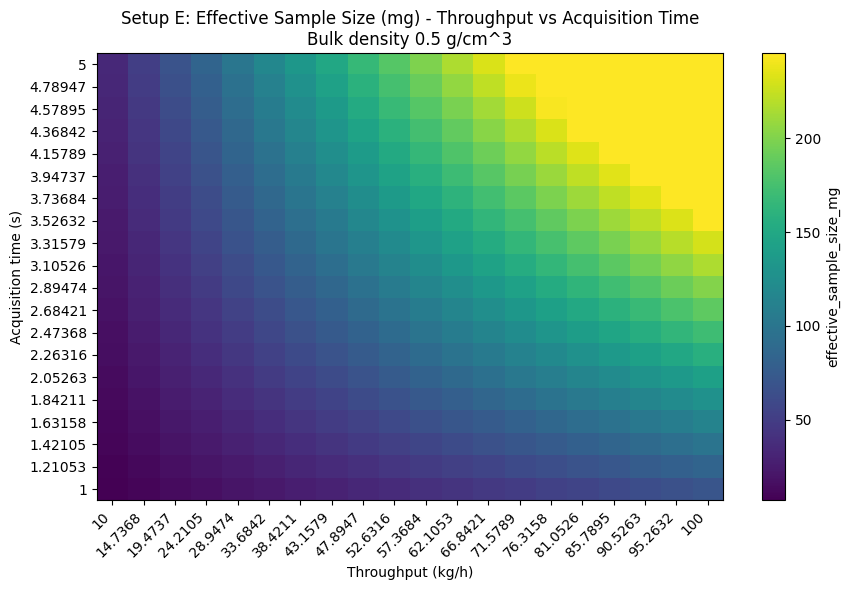

In [100]:
fig_heatmap_eff_sample_05, pivot_eff_sample_05 = plot_density_heatmap(
    df_3d,
    0.5,
    "Setup E: Effective Sample Size (mg) - Throughput vs Acquisition Time\nBulk density 0.5 g/cm^3",
)
plt.show()

## Plot 7: Heatmap - Effective Sample Size for 0.6 g/cm$^3$

This operating map shows how the refreshed new-mass proxy depends jointly on throughput and acquisition time for the covered-probe base geometry at a bulk density of 0.6 g/cm$^3$.

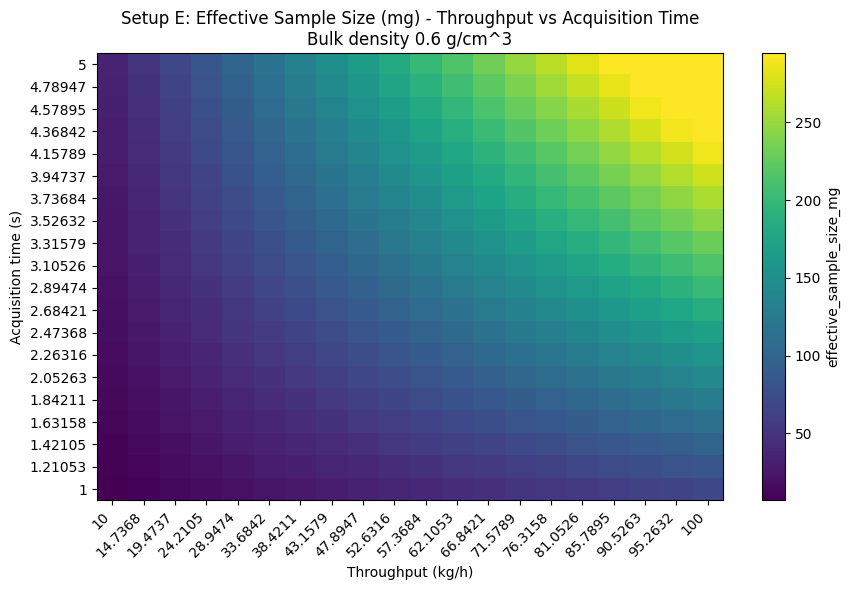

In [101]:
fig_heatmap_eff_sample_06, pivot_eff_sample_06 = plot_density_heatmap(
    df_3d,
    0.6,
    "Setup E: Effective Sample Size (mg) - Throughput vs Acquisition Time\nBulk density 0.6 g/cm^3",
)
plt.show()

## Plot 8: Time-Weighted Contribution Proxy vs Acquisition Time for Three Bulk Densities

This plot shows the simpler time-only proxy for Quantity 3, computed as instantaneous illuminated mass multiplied by acquisition time under a top-hat weighting assumption. It increases linearly with acquisition time for a fixed density scenario because it tracks accumulated exposure rather than refresh-limited replacement.

In [ ]:
fig_time_weighted_proxy_vs_time, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_acq_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(
        group["acquisition_time_s"],
        group["time_weighted_contribution_proxy_mg_s"],
        marker="o",
        label=f"{density:.1f} g/cm^3",
    )
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("Time-weighted contribution proxy (mg*s)")
ax.set_title("Setup E: Time-Weighted Contribution Proxy vs Acquisition Time\nCovered probe, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_time_weighted_proxy_vs_time.tight_layout()
plt.show()

## Results Interpretation

- the probe is treated as continuously covered by design during normal operation
- increasing penetration depth raises both instantaneous illuminated mass and the effective-sample-size ceiling for all three bulk-density scenarios
- increasing acquisition time raises refresh fraction and effective sample size until transport renewal approaches saturation, but the saturation time shifts with density because the throughput-derived local velocity changes
- lower bulk density increases the local volumetric transport rate at fixed throughput, which raises refresh fraction more quickly but does not automatically maximize every mass-based metric
- the time-weighted contribution proxy continues to rise with acquisition time even after refreshed new mass begins to saturate, because it tracks accumulated exposure rather than only unique replacement
- the 25 mm NIR spot is fixed across all sweeps, so the trends isolate density, depth, time, and throughput effects rather than changes in spot geometry

## Practical Implications

- bulk density differences across materials or operating states can materially change the effective sample mass seen by the NIR measurement even when throughput and spot geometry are unchanged
- penetration depth uncertainty still matters directly because it changes the illuminated mass and the resulting effective sampled mass proxy
- acquisition time selection trades off spectral quality against how much unique material is refreshed through the side-window NIR measurement
- a longer acquisition may increase integrated spectral contribution even after the unique refreshed mass per scan is close to saturation
- throughput directly controls powder velocity and therefore refresh rate near the measurement location, but the effect should now be interpreted together with the bulk-density scenario

## Limitations

- probe coverage is assumed guaranteed and is not stress-tested against abnormal operating states
- the rotating outlet valve is not modeled dynamically
- the local velocity near the probe is approximated from throughput and full pipe cross-section
- no turbulence, wall-slip, or recirculation model is included
- penetration depth is swept as an effective parameter, not derived from a wavelength-dependent optical model
- bulk density is treated as spatially uniform and fixed within each scenario
- bulk density and optical penetration depth may be correlated in reality, but are treated independently here
- the time-weighted contribution proxy is only a top-hat time-integration approximation, not a full space-time optical weighting model
- no particle-level sampling statistics or optical weighting correction are included

## Next Logical Extensions

- improved local velocity model near the covered probe
- coupled uncertainty bands for measurement depth and bulk density
- non-uniform optical weighting functions for the 25 mm NIR spot
- wavelength-dependent penetration-depth model
- material-specific calibration of density-dependent sampling behavior
- replace the top-hat time-weighted proxy with a full time- and space-dependent weighting field for spectral contribution
- calibration of the proxy against measured PAT spectra and tracer-style transport experiments

## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [ ]:
from pathlib import Path
import importlib
import sys

# Resolve project root dynamically (notebooks live in <project>/notebooks/)
notebook_file = globals().get("__vsc_ipynb_file__")
if notebook_file:
    project_root = Path(notebook_file).resolve().parent.parent
else:
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_structured_word_report = reporting_utils.build_structured_word_report
create_run_directory = reporting_utils.create_run_directory
dataframe_to_markdown_table = reporting_utils.dataframe_to_markdown_table
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

setup_name = "setup_e"
notebook_filename = "setup_E_PATrig_effective_sample_size.ipynb"
notebook_path = project_root / "notebooks" / notebook_filename
report_filename = "setup_e_report.docx"

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = df_density[[
    "bulk_density_g_per_cm3",
    "velocity_mm_s",
    "probe_mass_mg_instant",
    "new_mass_mg_per_acq",
    "mass_passed_mg_per_acq",
    "time_weighted_contribution_proxy_mg_s",
    "refresh_fraction_per_acq",
    "effective_sample_size_mg",
]].copy()

penetration_depth_table_df = df_penetration_density[[
    "bulk_density_g_per_cm3",
    "measurement_depth_cm",
    "velocity_mm_s",
    "probe_mass_mg_instant",
    "new_mass_mg_per_acq",
    "time_weighted_contribution_proxy_mg_s",
    "refresh_fraction_per_acq",
    "effective_sample_size_mg",
]].copy()
penetration_depth_table_df["measurement_depth_mm"] = penetration_depth_table_df["measurement_depth_cm"] * 10.0
penetration_depth_table_df = penetration_depth_table_df[[
    "bulk_density_g_per_cm3",
    "measurement_depth_cm",
    "measurement_depth_mm",
    "velocity_mm_s",
    "probe_mass_mg_instant",
    "new_mass_mg_per_acq",
    "time_weighted_contribution_proxy_mg_s",
    "refresh_fraction_per_acq",
    "effective_sample_size_mg",
]]

acquisition_time_table_df = df_acq_density[[
    "bulk_density_g_per_cm3",
    "acquisition_time_s",
    "velocity_mm_s",
    "probe_mass_mg_instant",
    "new_mass_mg_per_acq",
    "mass_passed_mg_per_acq",
    "time_weighted_contribution_proxy_mg_s",
    "refresh_fraction_per_acq",
    "effective_sample_size_mg",
]].copy()

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "penetration_depth_table": penetration_depth_table_df,
    "acquisition_time_table": acquisition_time_table_df,
    "input_summary": input_summary_df,
}
figures_to_save = {
    "plot_01_effective_sample_size_vs_penetration_depth_by_density": globals().get("fig_eff_sample_vs_depth"),
    "plot_02_instantaneous_probed_mass_vs_penetration_depth_by_density": globals().get("fig_probe_mass_vs_depth"),
    "plot_03_effective_sample_size_vs_acquisition_time_by_density": globals().get("fig_eff_sample_vs_time"),
    "plot_04_refresh_fraction_vs_acquisition_time_by_density": globals().get("fig_refresh_vs_time"),
    "plot_05_heatmap_effective_sample_size_density_04": globals().get("fig_heatmap_eff_sample_04"),
    "plot_06_heatmap_effective_sample_size_density_05": globals().get("fig_heatmap_eff_sample_05"),
    "plot_07_heatmap_effective_sample_size_density_06": globals().get("fig_heatmap_eff_sample_06"),
    "plot_08_time_weighted_contribution_proxy_vs_acquisition_time_by_density": globals().get("fig_time_weighted_proxy_vs_time"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Pipe diameter (cm)": base.pipe_diameter_cm,
    "NIR spot diameter (cm)": base.nir_spot_diameter_cm,
    "Base measurement depth (cm)": base.measurement_depth_cm,
    "Measurement depth sweep (mm)": "0.1 to 2.0",
    "Bulk density scenarios (g/cm^3)": ", ".join(f"{density:.1f}" for density in density_scenarios),
    "Base throughput (kg/h)": base.throughput_kg,
    "Acquisition time sweep (s)": "1.0 to 5.0",
    "Throughput sweep (kg/h)": "10 to 100",
    "Axial length model": base.axial_length_model,
}

metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "report_layout": "structured_scientific_report",
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

executive_summary_text = (
    "Setup E treats the PAT rig as a covered-probe vertical sampling interface in which powder continuously moves past a side-window non-contact NIR measurement location. The refactored study compares three bulk-density scenarios alongside penetration depth, acquisition time, and throughput-acquisition operating conditions while keeping the 25 mm spot geometry fixed so that instantaneous illuminated mass, refreshed new mass, and a simpler time-weighted contribution proxy can be compared mechanistically."
)

worked_example_report_df = baseline_display.rename(columns={"metric": "Quantity", "value": "Value"}).copy()
worked_example_body = (
    "The baseline case below reports the center density scenario, the base-case penetration depth, the instantaneous mass at the probe, the refreshed new mass during one acquisition, the total mass passed the NIR spot footprint, the time-weighted contribution proxy, and the resulting refresh fraction.\n\n"
    + dataframe_to_markdown_table(worked_example_report_df)
)

parameter_sweep_body = (
    "The Setup E analysis combines a discrete bulk-density comparison with a penetration-depth sweep by density, an acquisition-time sweep by density, and a throughput-by-acquisition-time sweep by density. This separates material-density sensitivity from optical-depth sensitivity and renewal-time sensitivity while holding the covered-probe geometry and 25 mm spot size fixed.\n\n"
    "- bulk density scenarios: 0.4, 0.5, and 0.6 g/cm^3\n"
    "- penetration depth swept from 0.1 to 2.0 mm in 0.1 mm steps for each density\n"
    "- acquisition time swept from 1.0 to 5.0 s for each density\n"
    "- throughput swept from 10 to 100 kg/h for each density\n"
    f"- NIR spot diameter fixed at {base.nir_spot_diameter_cm:.1f} cm\n"
    f"- axial sampling length model: {base.axial_length_model}\n\n"
    f"This produces {len(results_df)} modeled rows across the density-aware sweeps."
)

density_report_df = summary_table_df.copy()
for column in density_report_df.columns:
    density_report_df[column] = density_report_df[column].map(
        lambda value: f"{value:.4f}" if isinstance(value, (int, float, np.floating)) else value
    )
selected_results_body = (
    "The selected table below compares the three bulk-density scenarios at the common base operating condition so the reader can compare velocity, instantaneous illuminated mass, refreshed new mass, passed mass, time-weighted contribution proxy, refresh fraction, and effective sample size side by side.\n\n"
    + dataframe_to_markdown_table(density_report_df)
)

figure_section_body = (
    "The figures are ordered from one-dimensional density comparisons to density-specific operating maps, followed by the time-weighted contribution proxy versus acquisition time. This allows the reader to distinguish optical-volume effects, refresh-limited replacement, and time-integrated exposure behavior within the same report."
)
figure_entries = [
    {
        "filename": "plot_01_effective_sample_size_vs_penetration_depth_by_density.png",
        "caption": "Figure 1. Effective sample size versus penetration depth for bulk densities of 0.4, 0.5, and 0.6 g/cm^3 (fixed throughput: 95 kg/h; fixed acquisition time: 1.0 s; fixed NIR spot diameter: 25 mm).",
    },
    {
        "filename": "plot_02_instantaneous_probed_mass_vs_penetration_depth_by_density.png",
        "caption": "Figure 2. Instantaneous probed mass versus penetration depth for the three bulk-density scenarios (fixed throughput: 95 kg/h; fixed acquisition time: 1.0 s; fixed NIR spot diameter: 25 mm).",
    },
    {
        "filename": "plot_03_effective_sample_size_vs_acquisition_time_by_density.png",
        "caption": "Figure 3. Effective sample size versus acquisition time for the three bulk-density scenarios (fixed throughput: 95 kg/h; fixed penetration depth: 1.0 mm; fixed NIR spot diameter: 25 mm).",
    },
    {
        "filename": "plot_04_refresh_fraction_vs_acquisition_time_by_density.png",
        "caption": "Figure 4. Refresh fraction versus acquisition time for the three bulk-density scenarios (fixed throughput: 95 kg/h; fixed penetration depth: 1.0 mm; fixed NIR spot diameter: 25 mm).",
    },
    {
        "filename": "plot_05_heatmap_effective_sample_size_density_04.png",
        "caption": "Figure 5. Throughput-acquisition heatmap for effective sample size at 0.4 g/cm^3 bulk density (fixed penetration depth: 1.0 mm; fixed NIR spot diameter: 25 mm).",
    },
    {
        "filename": "plot_06_heatmap_effective_sample_size_density_05.png",
        "caption": "Figure 6. Throughput-acquisition heatmap for effective sample size at 0.5 g/cm^3 bulk density (fixed penetration depth: 1.0 mm; fixed NIR spot diameter: 25 mm).",
    },
    {
        "filename": "plot_07_heatmap_effective_sample_size_density_06.png",
        "caption": "Figure 7. Throughput-acquisition heatmap for effective sample size at 0.6 g/cm^3 bulk density (fixed penetration depth: 1.0 mm; fixed NIR spot diameter: 25 mm).",
    },
    {
        "filename": "plot_08_time_weighted_contribution_proxy_vs_acquisition_time_by_density.png",
        "caption": "Figure 8. Time-weighted contribution proxy versus acquisition time for bulk densities of 0.4, 0.5, and 0.6 g/cm^3 (fixed throughput: 95 kg/h; fixed penetration depth: 1.0 mm; fixed NIR spot diameter: 25 mm).",
    },
]

report_sections = [
    {"source": "notebook", "heading": "## Background"},
    {"source": "notebook", "heading": "## Objective"},
    {"source": "notebook", "heading": "## Theory"},
    {"source": "notebook", "heading": "## Interpreting Density, Velocity, and Throughput"},
    {"source": "notebook", "heading": "## Time- and Space-Weighted Contribution to the Spectrum"},
    {"source": "notebook", "heading": "## Assumptions"},
    {"source": "notebook", "heading": "## Compute Effective Sample Size Metrics"},
    {"source": "content", "heading": "Worked example", "body": worked_example_body},
    {"source": "content", "heading": "Model scenarios and sweep design", "body": parameter_sweep_body},
    {"source": "content", "heading": "Selected results table", "body": selected_results_body},
    {"source": "content", "heading": "Figures", "body": figure_section_body, "figures": figure_entries},
    {"source": "notebook", "heading": "## Results Interpretation"},
    {"source": "notebook", "heading": "## Practical Implications"},
    {"source": "notebook", "heading": "## Limitations"},
]
appendix_sections = [
    {"source": "notebook", "heading": "## Next Logical Extensions"},
]

build_structured_word_report(
    report_title="Setup E PAT Rig Effective Sample Size Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    output_filename=report_filename,
    executive_summary_text=executive_summary_text,
    parameter_summary=parameter_summary,
    report_sections=report_sections,
    appendix_sections=appendix_sections,
    csv_filenames=csv_files,
    figure_filenames=png_files,
)

print(f"Report run directory: {run_dir}")

Report run directory: C:\temp files\EFS\reports\setup_e\20260421_094153
